In [1]:
# Stage 04 - data acquisition and ingestion

In [2]:
# --- run me first ---
from pathlib import Path
import os, sys

if Path.cwd().name == 'notebooks':
    os.chdir('..')  # project/notebooks -> project

ROOT = Path.cwd()

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print('working from:', ROOT.name)

working from: project


In [3]:
import os
import datetime as dt
import pathlib

from typing import Dict, List

import requests
import pandas as pd
from dotenv import load_dotenv

In [4]:
DATA_RAW = pathlib.Path("data/raw")
DATA_RAW.mkdir(parents=True, exist_ok=True)

load_dotenv()

ALPHA_KEY = os.getenv("ALPHAVANTAGE_API_KEY")

print("Loaded ALPHAVANTAGE_API_KEY?", bool(ALPHA_KEY))
DATA_RAW.mkdir(parents=True, exist_ok=True)
ALPHA_KEY = os.getenv("ALPHAVANTAGE_API_KEY")
bool(ALPHA_KEY)

Loaded ALPHAVANTAGE_API_KEY? False


False

In [5]:
def safe_stamp():
    return dt.datetime.now().strftime("%Y%m%d-%H%M%S")
    dt.datetime.now()
    strftime("%Y%m%d-%H%M%S")

In [6]:
def safe_filename(prefix: str, meta: Dict[str, str]) -> str:
    mid = "_".join(
        [f"{k}-{str(v).replace(' ', '-')[:20]}" for k, v in meta.items()]
    )
    return f"{prefix}_{mid}_{safe_stamp()}.csv"

In [7]:
def validate_df(
    df: pd.DataFrame,
    required_cols: List[str],
    dtypes_map: Dict[str, str]
) -> Dict[str, str]:

    msgs = {}

    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        msgs['missing_cols'] = f"Missing columns: {missing}"

    for col, dtype in dtypes_map.items():
        if col in df.columns:
            try:
                if dtype == 'datetime64[ns]':
                    pd.to_datetime(df[col])
                elif dtype == 'float':
                    pd.to_numeric(df[col])
            except Exception as e:
                msgs[f'dtype_{col}'] = (
                    f"Failed to coerce {col} to {dtype}: {e}"
                )

    na_counts = df.isna().sum().sum()
    msgs['na_total'] = f"Total NA values: {na_counts}"

    return msgs

In [8]:
SYMBOL = "SPY"
use_alpha = bool(ALPHA_KEY)

print("Using Alpha Vantage:", use_alpha)
print("Using Alpha Vantage:", use_alpha)

if use_alpha:
    url = "https://www.alphavantage.co/query"

    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": SYMBOL,
        "outputsize": "compact",
        "apikey": ALPHA_KEY,
        "datatype": "json"
    }

    r = requests.get(
        url,
        params=params,
        timeout=30
    )

    r.raise_for_status()

    js = r.json()

    key = [
        k for k in js.keys()
        if "Time Series" in k
    ]

    if not key:
        print(
            "Alpha Vantage returned no series:",
            str(list(js.values())[0])[:150]
        )
        use_alpha = False

Using Alpha Vantage: False
Using Alpha Vantage: False


In [9]:
if use_alpha:

    series = js[key[0]]

    df_api = (
        pd.DataFrame(series)
        .T
        .rename_axis("date")
        .reset_index()
    )

    df_api = (
        df_api[["date", "4. close"]]
        .rename(columns={"4. close": "close"})
    )

    df_api["date"] = pd.to_datetime(
        df_api["date"]
    )

    df_api["close"] = pd.to_numeric(
        df_api["close"]
    )

In [10]:
if not use_alpha:

    import yfinance as yf

    df_api = (
        yf.download(
            SYMBOL,
            period="10y",
            interval="1d",
            auto_adjust=False,
            multi_level_index=False
        )
        .reset_index()[["Date", "Close"]]
    )

    df_api.columns = ["date", "close"]

[*********************100%***********************]  1 of 1 completed


In [11]:
df_api = (
    df_api
    .sort_values("date")
    .reset_index(drop=True)
)

In [12]:
msgs = validate_df(
    df_api,
    required_cols=["date", "close"],
    dtypes_map={
        "date": "datetime64[ns]",
        "close": "float"
    }
)

print(msgs)

{'na_total': 'Total NA values: 0'}


In [13]:
fname = safe_filename(
    prefix="api",
    meta={
        "source": "alpha" if use_alpha else "yfinance",
        "symbol": SYMBOL
    }
)

out_path = DATA_RAW / fname

df_api.to_csv(
    out_path,
    index=False
)

print("Saved:", out_path)

Saved: data\raw\api_source-yfinance_symbol-SPY_20260826-172655.csv


In [14]:
# Stage 05 — Data Storage

In [15]:
import os
import pathlib
import pandas as pd
from dotenv import load_dotenv

In [16]:
load_dotenv()

RAW_DIR = pathlib.Path(
    os.getenv("DATA_DIR_RAW", "data/raw")
)

PROC_DIR = pathlib.Path(
    os.getenv("DATA_DIR_PROCESSED", "data/processed")
)

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print("RAW_DIR:", RAW_DIR.resolve())
print("PROC_DIR:", PROC_DIR.resolve())

RAW_DIR: C:\Users\PC\bootcamp_chen_he\project\data\raw
PROC_DIR: C:\Users\PC\bootcamp_chen_he\project\data\processed


In [17]:
spy_files = sorted(
    RAW_DIR.glob("*SPY*.csv")
)

print("SPY raw files found:", len(spy_files))
latest_spy_path = spy_files[-1]

print("Loading:", latest_spy_path)

SPY raw files found: 7
Loading: data\raw\api_source-yfinance_symbol-SPY_20260826-172655.csv


In [18]:
spy_raw = pd.read_csv(
    latest_spy_path,
    parse_dates=["date"]
)

In [19]:
def validate_spy_storage(df):
    checks = {
        "not_empty": not df.empty,
        "date_present": "date" in df.columns,
        "close_present": "close" in df.columns,
    }

    if "date" in df.columns:
        checks["date_is_datetime"] = (
            pd.api.types.is_datetime64_any_dtype(df["date"])
        )

    if "close" in df.columns:
        checks["close_is_numeric"] = (
            pd.api.types.is_numeric_dtype(df["close"])
        )

    return checks

In [20]:
storage_checks = validate_spy_storage(spy_raw)

print(storage_checks)

{'not_empty': True, 'date_present': True, 'close_present': True, 'date_is_datetime': True, 'close_is_numeric': True}


In [21]:
display(spy_raw.head())

print("Shape:", spy_raw.shape)

print(
    "Date range:",
    spy_raw["date"].min(),
    "to",
    spy_raw["date"].max()
)

,date,close
0,2016-08-29,218.360001
1,2016-08-30,218.000000
2,2016-08-31,217.380005
3,2016-09-01,217.389999
4,2016-09-02,218.369995


Shape: (2512, 2)
Date range: 2016-08-29 00:00:00 to 2026-08-26 00:00:00


In [22]:
# Stage 06 — Data Preprocessing

In [23]:
spy = spy_raw.copy()
spy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2512 non-null   datetime64[ns]
 1   close   2512 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


In [24]:
spy.head()

,date,close
0,2016-08-29,218.360001
1,2016-08-30,218.000000
2,2016-08-31,217.380005
3,2016-09-01,217.389999
4,2016-09-02,218.369995


In [25]:
spy.isna().sum()

date     0
close    0
dtype: int64

In [26]:
spy.duplicated().sum()

np.int64(0)

In [27]:
spy["date"].duplicated().sum()

np.int64(0)

In [28]:
from src.cleaning import clean_spy_data
spy_clean = clean_spy_data(spy_raw)
print("Raw shape:", spy_raw.shape)
print("Clean shape:", spy_clean.shape)

Raw shape: (2512, 2)
Clean shape: (2512, 2)


In [29]:
print(
    "Missing values:"
)
print(spy_clean.isna().sum())

Missing values:
date     0
close    0
dtype: int64


In [30]:
print(
    "Duplicate dates:",
    spy_clean["date"].duplicated().sum()
)

Duplicate dates: 0


In [31]:
print(
    "Non-positive close prices:",
    (spy_clean["close"] <= 0).sum()
)

Non-positive close prices: 0


In [32]:
spy_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    2512 non-null   datetime64[ns]
 1   close   2512 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 39.4 KB


In [33]:
spy_clean["date"].is_monotonic_increasing

True

In [34]:
processed_path = PROC_DIR / "spy_clean.csv"

spy_clean.to_csv(
    processed_path,
    index=False
)

print(
    "Saved cleaned data to:",
    processed_path
)

Saved cleaned data to: data\processed\spy_clean.csv


In [35]:
# Stage 07 — Outlier Analysis

In [36]:
spy_outliers = spy_clean.copy()

spy_outliers["daily_return"] = (
    spy_outliers["close"].pct_change()
)

spy_outliers.head()

,date,close,daily_return
0,2016-08-29,218.360001,NaN
1,2016-08-30,218.000000,-0.001649
2,2016-08-31,217.380005,-0.002844
3,2016-09-01,217.389999,0.000046
4,2016-09-02,218.369995,0.004508


In [37]:
from src.outliers import detect_outliers_iqr

In [38]:
spy_outliers["outlier_iqr"] = (
    detect_outliers_iqr(
        spy_outliers["daily_return"],
        k=1.5
    )
)
spy_outliers[
    spy_outliers["outlier_iqr"]
].head()

,date,close,daily_return,outlier_iqr
8,2016-09-09,213.279999,-0.023935,True
49,2016-11-07,213.149994,0.022057,True
360,2018-02-02,275.450012,-0.021770,True
361,2018-02-05,263.929993,-0.041823,True
364,2018-02-08,257.630005,-0.037509,True


In [39]:
spy_outliers["outlier_iqr"].value_counts()

outlier_iqr
False    2347
True      165
Name: count, dtype: int64

In [40]:
returns_all = spy_outliers[
    "daily_return"
].dropna()

returns_filtered = spy_outliers.loc[
    ~spy_outliers["outlier_iqr"],
    "daily_return"
].dropna()

sensitivity = pd.DataFrame({
    "all_data": [
        returns_all.mean(),
        returns_all.std(),
        returns_all.min(),
        returns_all.max()
    ],

    "without_iqr_outliers": [
        returns_filtered.mean(),
        returns_filtered.std(),
        returns_filtered.min(),
        returns_filtered.max()
    ]
},
index=[
    "mean_return",
    "std_return",
    "min_return",
    "max_return"
])

sensitivity

,all_data,without_iqr_outliers
mean_return,0.000565,0.001041
std_return,0.011359,0.007337
min_return,-0.109424,-0.018158
max_return,0.105019,0.019981


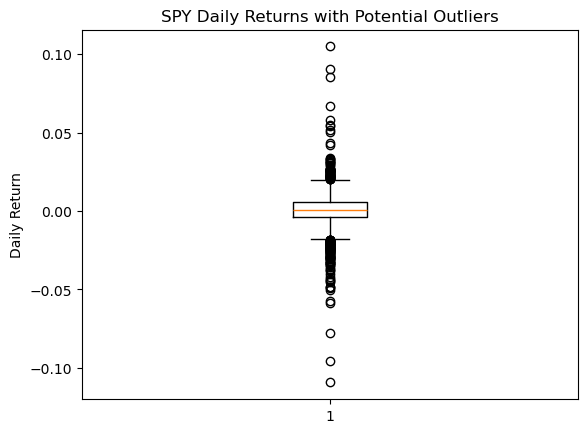

In [41]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(
    returns_all,
    vert=True
)

plt.title(
    "SPY Daily Returns with Potential Outliers"
)

plt.ylabel(
    "Daily Return"
)

plt.show()

In [42]:
outlier_path = (
    PROC_DIR /
    "spy_with_outlier_flags.csv"
)

spy_outliers.to_csv(
    outlier_path,
    index=False
)

print(
    "Saved:",
    outlier_path
)

Saved: data\processed\spy_with_outlier_flags.csv


In [43]:
# Stage 08 - exploratory data analysis

In [44]:
spy = pd.read_csv(
    "data/processed/spy_with_outlier_flags.csv",
    parse_dates=["date"]
)

spy.head()

,date,close,daily_return,outlier_iqr
0,2016-08-29,218.360001,NaN,False
1,2016-08-30,218.000000,-0.001649,False
2,2016-08-31,217.380005,-0.002844,False
3,2016-09-01,217.389999,0.000046,False
4,2016-09-02,218.369995,0.004508,False


In [45]:
from src.eda import eda_summary

In [46]:
summary = eda_summary(spy)

In [47]:
summary["shape"]

(2512, 4)

In [48]:
summary["missing"]

{'date': 0, 'close': 0, 'daily_return': 1, 'outlier_iqr': 0}

In [49]:
summary["numeric_profile"]

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
close,2512.0,409.565860,145.310269,208.550003,281.869995,394.414993,500.400002,777.880005,0.674116,-0.519754
daily_return,2511.0,0.000565,0.011359,-0.109424,-0.003700,0.000696,0.005983,0.105019,-0.310669,14.638689


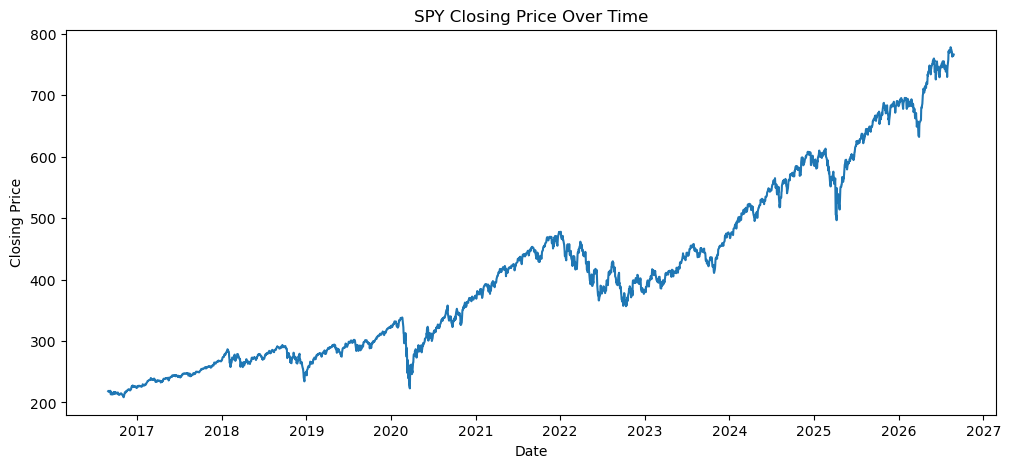

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    spy["date"],
    spy["close"]
)

plt.title(
    "SPY Closing Price Over Time"
)

plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

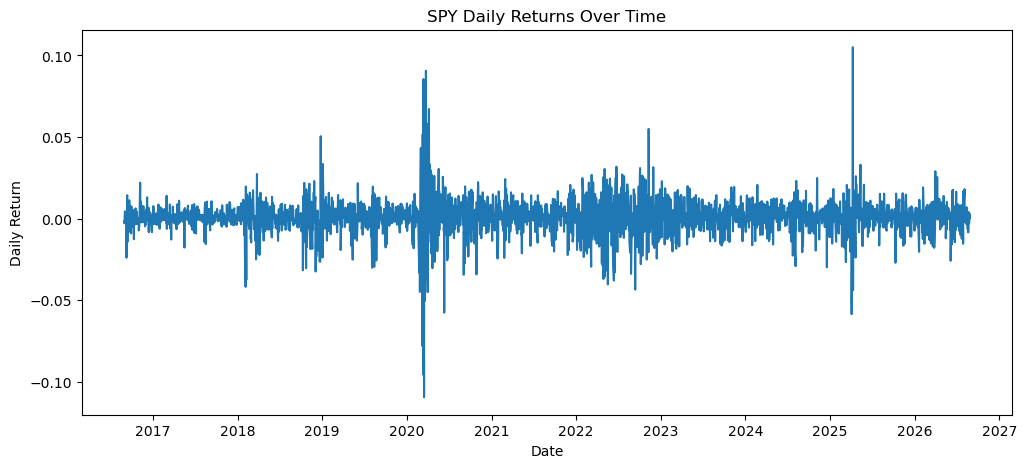

In [51]:
plt.figure(figsize=(12, 5))

plt.plot(
    spy["date"],
    spy["daily_return"]
)

plt.title(
    "SPY Daily Returns Over Time"
)

plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

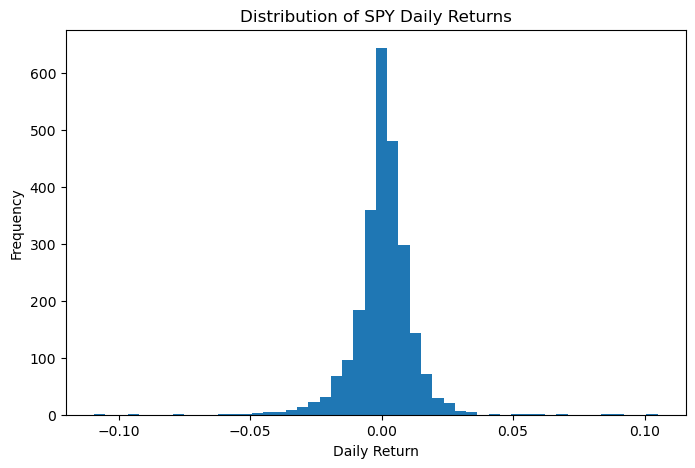

In [52]:
plt.figure(figsize=(8, 5))

plt.hist(
    spy["daily_return"].dropna(),
    bins=50
)

plt.title(
    "Distribution of SPY Daily Returns"
)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

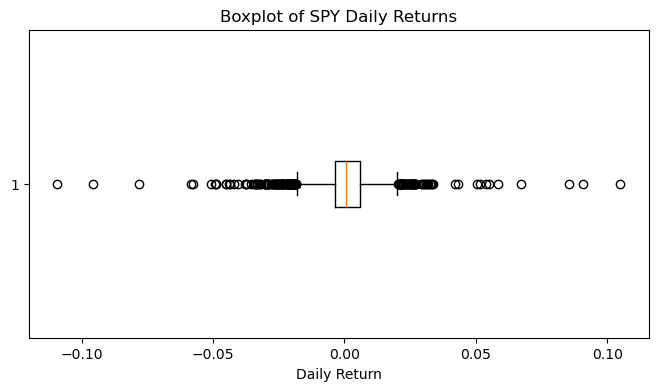

In [53]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    spy["daily_return"].dropna(),
    vert=False
)

plt.title(
    "Boxplot of SPY Daily Returns"
)

plt.xlabel("Daily Return")

plt.show()

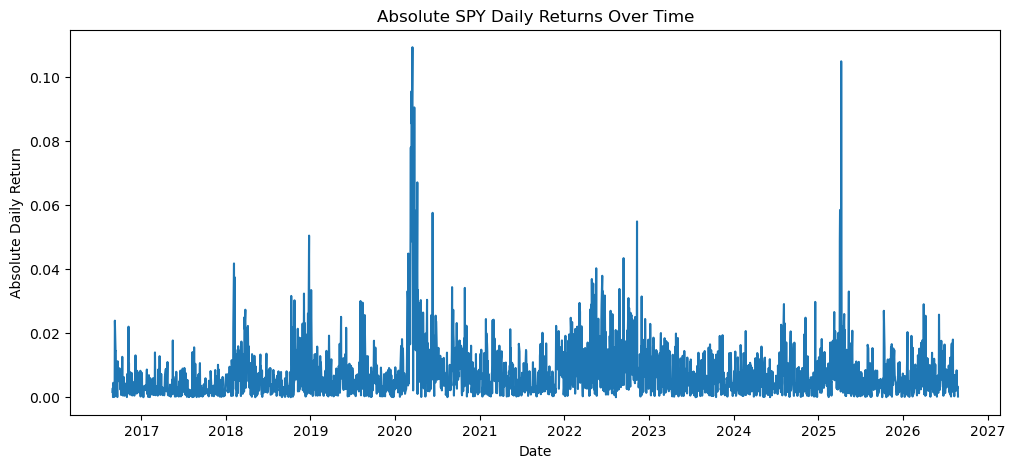

In [54]:
spy["abs_return"] = (
    spy["daily_return"].abs()
)
plt.figure(figsize=(12, 5))

plt.plot(
    spy["date"],
    spy["abs_return"]
)

plt.title(
    "Absolute SPY Daily Returns Over Time"
)

plt.xlabel("Date")
plt.ylabel("Absolute Daily Return")

plt.show()

In [55]:
# Stage 09 — Feature Engineering

In [56]:
from src.features import create_spy_features
spy_features = create_spy_features(
    spy_outliers
)

spy_features.head(25)

,date,close,daily_return,outlier_iqr,abs_return,return_5d,rolling_vol_5,rolling_vol_20,lag_return_1,lag_abs_return_1
0,2016-08-29,218.360001,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN
1,2016-08-30,218.000000,-0.001649,False,0.001649,NaN,NaN,NaN,NaN,NaN
2,2016-08-31,217.380005,-0.002844,False,0.002844,NaN,NaN,NaN,-0.001649,0.001649
3,2016-09-01,217.389999,0.000046,False,0.000046,NaN,NaN,NaN,-0.002844,0.002844
4,2016-09-02,218.369995,0.004508,False,0.004508,NaN,NaN,NaN,0.000046,0.000046
5,2016-09-06,219.029999,0.003022,False,0.003022,0.003068,0.003097,NaN,0.004508,0.004508
6,2016-09-07,219.009995,-0.000091,False,0.000091,0.004633,0.002883,NaN,0.003022,0.003022
7,2016-09-08,218.509995,-0.002283,False,0.002283,0.005198,0.002705,NaN,-0.000091,0.000091
8,2016-09-09,213.279999,-0.023935,True,0.023935,-0.018906,0.011587,NaN,-0.002283,0.002283
9,2016-09-12,216.339996,0.014347,False,0.014347,-0.009296,0.013938,NaN,-0.023935,0.023935


In [57]:
feature_cols = [
    "daily_return",
    "abs_return",
    "return_5d",
    "rolling_vol_5",
    "rolling_vol_20",
    "lag_return_1",
    "lag_abs_return_1"
]

spy_features[
    ["date", "close"] + feature_cols
].tail()

,date,close,daily_return,abs_return,return_5d,rolling_vol_5,rolling_vol_20,lag_return_1,lag_abs_return_1
2507,2026-08-20,762.599976,-0.008400,0.008400,-0.019643,0.004145,0.008289,0.002098,0.002098
2508,2026-08-21,765.719971,0.004091,0.004091,-0.013680,0.005527,0.008304,-0.008400,0.008400
2509,2026-08-24,763.469971,-0.002938,0.002938,-0.011907,0.005423,0.008366,0.004091,0.004091
2510,2026-08-25,765.909973,0.003196,0.003196,-0.002007,0.005239,0.008372,-0.002938,0.002938
2511,2026-08-26,766.080017,0.000222,0.000222,-0.003875,0.005081,0.007362,0.003196,0.003196


In [58]:
import importlib
import src.features

importlib.reload(src.features)

from src.features import (
    create_spy_features,
    create_future_volatility_target
)

In [59]:
spy_features = create_future_volatility_target(
    spy_features,
    horizon=5
)

In [60]:
spy_features.head(25)

,date,close,daily_return,outlier_iqr,abs_return,return_5d,rolling_vol_5,rolling_vol_20,lag_return_1,lag_abs_return_1,future_vol_5d
0,2016-08-29,218.360001,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,0.003097
1,2016-08-30,218.000000,-0.001649,False,0.001649,NaN,NaN,NaN,NaN,NaN,0.002883
2,2016-08-31,217.380005,-0.002844,False,0.002844,NaN,NaN,NaN,-0.001649,0.001649,0.002705
3,2016-09-01,217.389999,0.000046,False,0.000046,NaN,NaN,NaN,-0.002844,0.002844,0.011587
4,2016-09-02,218.369995,0.004508,False,0.004508,NaN,NaN,NaN,0.000046,0.000046,0.013938
5,2016-09-06,219.029999,0.003022,False,0.003022,0.003068,0.003097,NaN,0.004508,0.004508,0.014593
6,2016-09-07,219.009995,-0.000091,False,0.000091,0.004633,0.002883,NaN,0.003022,0.003022,0.014569
7,2016-09-08,218.509995,-0.002283,False,0.002283,0.005198,0.002705,NaN,-0.000091,0.000091,0.016157
8,2016-09-09,213.279999,-0.023935,True,0.023935,-0.018906,0.011587,NaN,-0.002283,0.002283,0.012156
9,2016-09-12,216.339996,0.014347,False,0.014347,-0.009296,0.013938,NaN,-0.023935,0.023935,0.009344


In [61]:
# Stage 10 — Modeling

In [62]:
feature_cols = [
    "rolling_vol_5",
    "rolling_vol_20",
    "return_5d",
    "lag_return_1",
    "lag_abs_return_1"
]

target_col = "future_vol_5d"

In [63]:
model_df = (
    spy_features[
        ["date"] + feature_cols + [target_col]
    ]
    .dropna()
    .copy()
)

In [64]:
model_df.head()

,date,rolling_vol_5,rolling_vol_20,return_5d,lag_return_1,lag_abs_return_1,future_vol_5d
20,2016-09-27,0.008362,0.008893,0.010074,-0.008102,0.008102,0.006927
21,2016-09-28,0.006992,0.008975,0.003799,0.006208,0.006208,0.006818
22,2016-09-29,0.007322,0.009173,-0.011511,0.004964,0.004964,0.005085
23,2016-09-30,0.008172,0.009352,0.001435,-0.009047,0.009047,0.003770
24,2016-10-03,0.007021,0.009296,0.007188,0.007546,0.007546,0.004591


In [65]:
model_df.shape

(2487, 7)

In [66]:
cut = int(
    len(model_df) * 0.8
)

train = model_df.iloc[:cut].copy()
test = model_df.iloc[cut:].copy()

In [67]:
X_train = train[feature_cols]
y_train = train[target_col]

X_test = test[feature_cols]
y_test = test[target_col]

In [68]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (1989, 5)
Test: (498, 5)


In [69]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [70]:
model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "regression",
        LinearRegression()
    )
])

In [71]:
model.fit(
    X_train,
    y_train
)

,steps,"[('scaler', ...), ('regression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None


In [72]:
y_pred = model.predict(
    X_test
)

In [73]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [74]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = (
    mean_squared_error(
        y_test,
        y_pred
    ) ** 0.5
)

r2 = r2_score(
    y_test,
    y_pred
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 0.0033709179293472153
RMSE: 0.005764081063280983
R²: 0.2516511888143048


In [75]:
import matplotlib.pyplot as plt

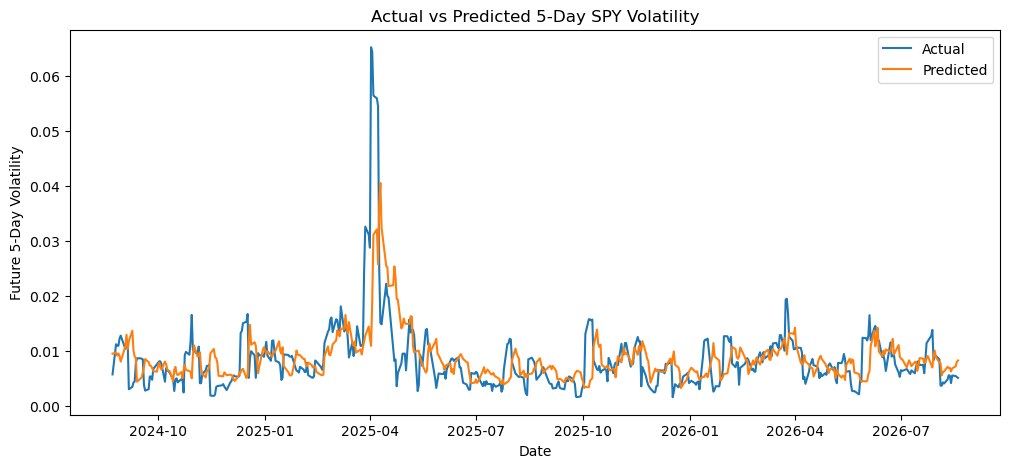

In [76]:
plt.figure(figsize=(12, 5))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    y_pred,
    label="Predicted"
)

plt.title(
    "Actual vs Predicted 5-Day SPY Volatility"
)

plt.xlabel("Date")
plt.ylabel("Future 5-Day Volatility")

plt.legend()
plt.show()

In [77]:
residuals = (
    y_test.to_numpy()
    - y_pred
)

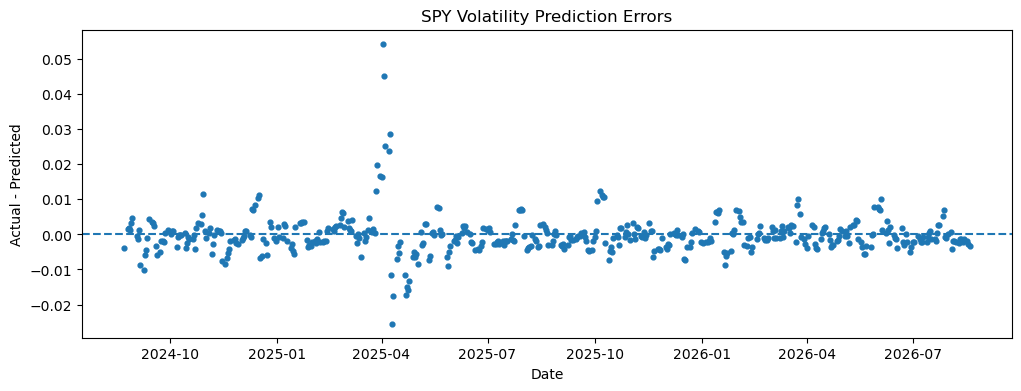

In [78]:
plt.figure(figsize=(12, 4))

plt.scatter(
    test["date"],
    residuals,
    s=12
)

plt.axhline(
    0,
    linestyle="--"
)

plt.title(
    "SPY Volatility Prediction Errors"
)

plt.xlabel("Date")
plt.ylabel(
    "Actual - Predicted"
)

plt.show()

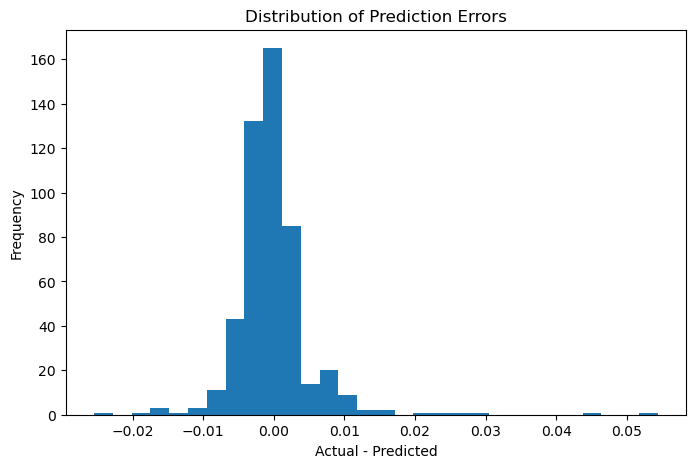

In [79]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    "Distribution of Prediction Errors"
)

plt.xlabel(
    "Actual - Predicted"
)

plt.ylabel("Frequency")

plt.show()

In [80]:
baseline_pred = (
    test["rolling_vol_5"]
    .to_numpy()
)

In [81]:
baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = (
    mean_squared_error(
        y_test,
        baseline_pred
    ) ** 0.5
)

print(
    "Model MAE:",
    mae
)

print(
    "Baseline MAE:",
    baseline_mae
)

print(
    "Model RMSE:",
    rmse
)

print(
    "Baseline RMSE:",
    baseline_rmse
)

Model MAE: 0.0033709179293472153
Baseline MAE: 0.004313362903801271
Model RMSE: 0.005764081063280983
Baseline RMSE: 0.007262603174259952


In [82]:
linreg = model.named_steps[
    "regression"
]

In [83]:
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": linreg.coef_
})

coef_table

,feature,coefficient
0,rolling_vol_5,0.002162
1,rolling_vol_20,0.002600
2,return_5d,-0.001565
3,lag_return_1,-0.000369
4,lag_abs_return_1,0.000779


In [84]:
# Stage 11 — Evaluation & Risk Communication

In [85]:
performance = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R²"
    ],
    "Value": [
        mae,
        rmse,
        r2
    ]
})

performance

,Metric,Value
0,MAE,0.003371
1,RMSE,0.005764
2,R²,0.251651


In [86]:
import importlib
import src.evaluation

importlib.reload(src.evaluation)
from src.evaluation import (
    regression_metrics,
    bootstrap_rmse
)

In [87]:
metrics = regression_metrics(
    y_test,
    y_pred
)

metrics

{'MAE': 0.0033709179293472153,
 'RMSE': 0.005764081063280983,
 'R2': 0.2516511888143048}

In [88]:
rmse_boot = bootstrap_rmse(
    y_test,
    y_pred,
    n_boot=1000,
    seed=42
)

In [89]:
import numpy as np
rmse_ci = np.percentile(
    rmse_boot,
    [2.5, 97.5]
)

print(
    "RMSE 95% Bootstrap CI:",
    rmse_ci
)

RMSE 95% Bootstrap CI: [0.0045189  0.00700902]


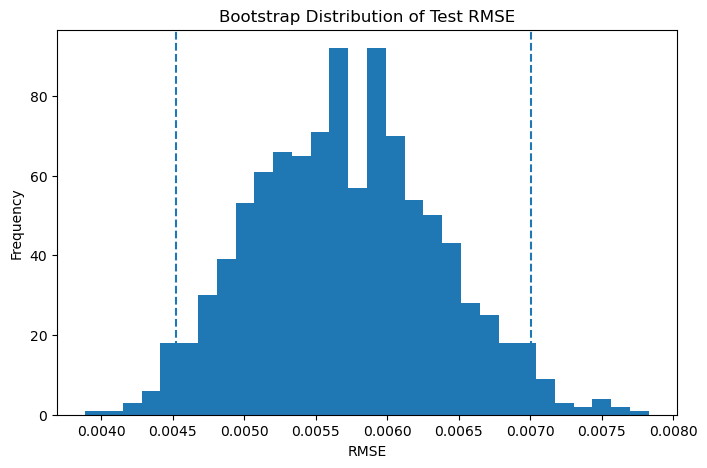

In [90]:
plt.figure(figsize=(8, 5))

plt.hist(
    rmse_boot,
    bins=30
)

plt.axvline(
    rmse_ci[0],
    linestyle="--"
)

plt.axvline(
    rmse_ci[1],
    linestyle="--"
)

plt.title(
    "Bootstrap Distribution of Test RMSE"
)

plt.xlabel("RMSE")
plt.ylabel("Frequency")

plt.show()

In [91]:
from sklearn.preprocessing import (
    PolynomialFeatures
)

In [92]:
poly_model = Pipeline([
    (
        "poly",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "regression",
        LinearRegression()
    )
])

In [93]:
poly_model.fit(
    X_train,
    y_train
)

poly_pred = poly_model.predict(
    X_test
)

In [94]:
poly_metrics = regression_metrics(
    y_test,
    poly_pred
)

poly_metrics

{'MAE': 0.003521158248546808,
 'RMSE': 0.006284912109225808,
 'R2': 0.11030258093546608}

In [95]:
scenario_results = pd.DataFrame([
    {
        "Scenario": "Linear",
        **regression_metrics(
            y_test,
            y_pred
        )
    },

    {
        "Scenario": "Polynomial",
        **regression_metrics(
            y_test,
            poly_pred
        )
    }
])

scenario_results

,Scenario,MAE,RMSE,R2
0,Linear,0.003371,0.005764,0.251651
1,Polynomial,0.003521,0.006285,0.110303


In [96]:
vol_threshold = (
    y_test.quantile(0.75)
)

In [97]:
high_vol_mask = (
    y_test >= vol_threshold
)

normal_vol_mask = (
    y_test < vol_threshold
)

In [98]:
high_vol_rmse = (
    mean_squared_error(
        y_test[high_vol_mask],
        y_pred[high_vol_mask]
    ) ** 0.5
)

normal_vol_rmse = (
    mean_squared_error(
        y_test[normal_vol_mask],
        y_pred[normal_vol_mask]
    ) ** 0.5
)

In [99]:
stress_results = pd.DataFrame({
    "Market Condition": [
        "Normal Volatility",
        "High Volatility"
    ],
    "RMSE": [
        normal_vol_rmse,
        high_vol_rmse
    ]
})

stress_results

,Market Condition,RMSE
0,Normal Volatility,0.003381
1,High Volatility,0.009913


In [100]:
evaluation_df = test[
    ["date"]
].copy()

evaluation_df["actual"] = (
    y_test.to_numpy()
)

evaluation_df["predicted"] = (
    y_pred
)

evaluation_df["error"] = (
    evaluation_df["actual"]
    - evaluation_df["predicted"]
)

In [101]:
evaluation_df.loc[
    high_vol_mask.to_numpy(),
    "error"
].mean()

np.float64(0.0043486798710530876)

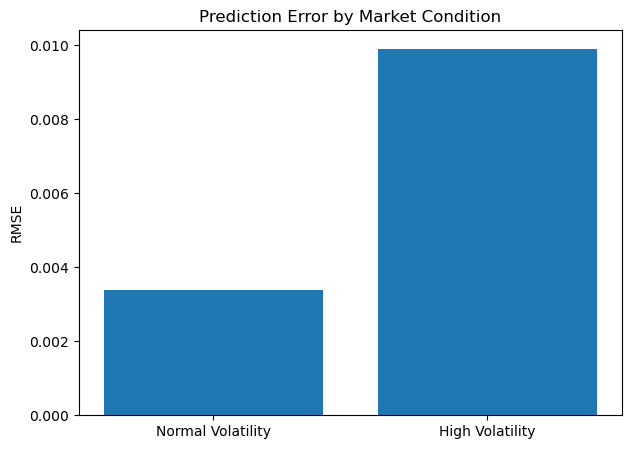

In [102]:
plt.figure(figsize=(7, 5))

plt.bar(
    stress_results[
        "Market Condition"
    ],
    stress_results["RMSE"]
)

plt.title(
    "Prediction Error by Market Condition"
)

plt.ylabel("RMSE")

plt.show()